In [1]:
library(data.table)

clim <- fread("derived_tables/site_year_climate_monthly_metrics_selected_sites.csv")

# sanity
uniqueN(clim$SITE_ID)
range(clim$year)

[1] 348

[1] 1994 2024

In [2]:
efp_dir <- "efp_site_year_results"

efp_files <- list.files(
  efp_dir,
  pattern = "_EFP_yearly\\.csv$",
  full.names = TRUE
)

cat(sprintf("Found %d EFP files\n", length(efp_files)))

Found 399 EFP files


In [3]:
read_efp_file <- function(f) {
  dt <- fread(f)

  # extract site from filename
  site_id <- sub("_EFP_yearly\\.csv$", "", basename(f))
  dt[, SITE_ID := site_id]

  return(dt[])
}

efp_all <- rbindlist(lapply(efp_files, read_efp_file), fill = TRUE)

In [6]:
names(efp_all)

[1] "uWUE"          "ETmax"         "precipAvail"   "Gavail"       
 [5] "GSmax"         "CO2avail"      "G1"            "EF"           
 [9] "EFampl"        "GPPsat"        "NEPmax"        "Rb"           
[13] "Rbmax"         "aCUE"          "TZ"            "nyears"       
[17] "SITE_ID"       "year"          "LOCATION_LAT"  "LOCATION_LONG"
[21] "LOCATION_ELEV" "IGBP"

In [ ]:
#fwrite(efp_all, "348EFP_yearly.csv")

In [5]:
# keep only sites that exist in climate table
efp_filt <- efp_all[SITE_ID %in% clim$SITE_ID]

# keep only years that exist per site
efp_filt <- efp_filt[
  clim,
  on = .(SITE_ID, year),
  nomatch = 0
]

In [6]:
efp_climate <- merge(
  efp_filt,
  clim,
  by = c("SITE_ID", "year"),
  all = FALSE
)

In [7]:
dir.create("derived_tables", showWarnings = FALSE, recursive = TRUE)

fwrite(
  efp_climate,
  "derived_tables/EFP_site_year_with_climate_monthly_quantiles.csv"
)

In [9]:
efp_climate <- fread("derived_tables/EFP_site_year_with_climate.csv")

In [8]:
# 1) one row per site-year?
efp_climate[, .N, by = .(SITE_ID, year)][N > 1]

# 2) site coverage
length(unique(efp_climate$SITE_ID))

# 3) year coverage
efp_climate[, .(
  n_years = uniqueN(year),
  min_year = min(year),
  max_year = max(year)
), by = SITE_ID][order(-n_years)]#[1:10]

SITE_ID,year,N
<chr>,<int>,<int>


[1] 348

SITE_ID,n_years,min_year,max_year
<chr>,<int>,<int>,<int>
DK-Sor,28,1996,2024
IT-Ren,26,1999,2024
RU-Fyo,26,1998,2023
CA-Cbo,25,1995,2020
US-Ton,24,2001,2024
US-ARM,22,2003,2024
IL-Yat,21,2000,2020
US-Ho2,21,2002,2023
US-Me2,21,2002,2022


In [9]:
deadtree500 <- fread("derived_tables/forest_deadwood_500m_by_site_year_with_lossproxy.csv")

In [12]:
View(deadtree500)

site_id,year,forest_mean_pct_500m,deadwood_mean_pct_500m,forest_change_pp_from_baseline,forest_change_pct_from_baseline,forest_change_pp_yoy
<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
AR-SLu,2016,0.2881305,0.50062370,0.00000000,0,NA
AR-SLu,2017,12.3927059,0.79249614,12.10457540,0,12.10457540
AR-SLu,2018,9.4717855,0.10507409,9.18365502,0,-2.92092037
AR-SLu,2019,4.8412414,0.34605598,4.55311084,0,-4.63054419
AR-SLu,2020,4.9443693,0.08756174,4.65623879,0,0.10312796
AR-SLu,2021,7.9149828,0.33986929,7.62685227,0,2.97061348
AR-SLu,2022,3.8991172,0.07174575,3.61098671,0,-4.01586556
AR-SLu,2023,4.3549371,0.40198573,4.06680655,0,0.45581985
AR-SLu,2024,3.8458815,0.91997206,3.55775094,0,-0.50905561


In [23]:
library(data.table)
library(ggplot2)

# get first site_id
first_site <- unique(deadtree500$site_id)[2]

dt_site <- deadtree500[site_id == first_site]

In [24]:
View(dt_site)

site_id,year,forest_mean_pct_500m,deadwood_mean_pct_500m,forest_change_pp_from_baseline,forest_change_pct_from_baseline,forest_change_pp_yoy
<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
AR-Vir,2017,81.86059,1.7986829,0.000000,0,NA
AR-Vir,2018,91.47164,1.7706432,9.611053,0,9.611053
AR-Vir,2019,94.68623,3.6042008,12.825638,0,3.214584
AR-Vir,2020,96.26768,2.8590529,14.407089,0,1.581451
AR-Vir,2021,68.05360,0.4025845,-13.806992,0,-28.214081
AR-Vir,2022,66.39929,5.5304098,-15.461296,0,-1.654305
AR-Vir,2023,12.23075,1.6243078,-69.629834,0,-54.168538
AR-Vir,2024,16.43167,0.6238088,-65.428915,0,4.200919
AR-Vir,2025,29.43327,1.9084966,-52.427319,0,13.001596


In [25]:
library(data.table)

dt_long <- melt(
  dt_site,
  id.vars = "year",
  measure.vars = c("forest_mean_pct_500m", "deadwood_mean_pct_500m"),
  variable.name = "Variable",
  value.name = "Value"
)

dt_long[, Variable := factor(
  Variable,
  levels = c("forest_mean_pct_500m", "deadwood_mean_pct_500m"),
  labels = c("Forest", "Deadwood")
)]

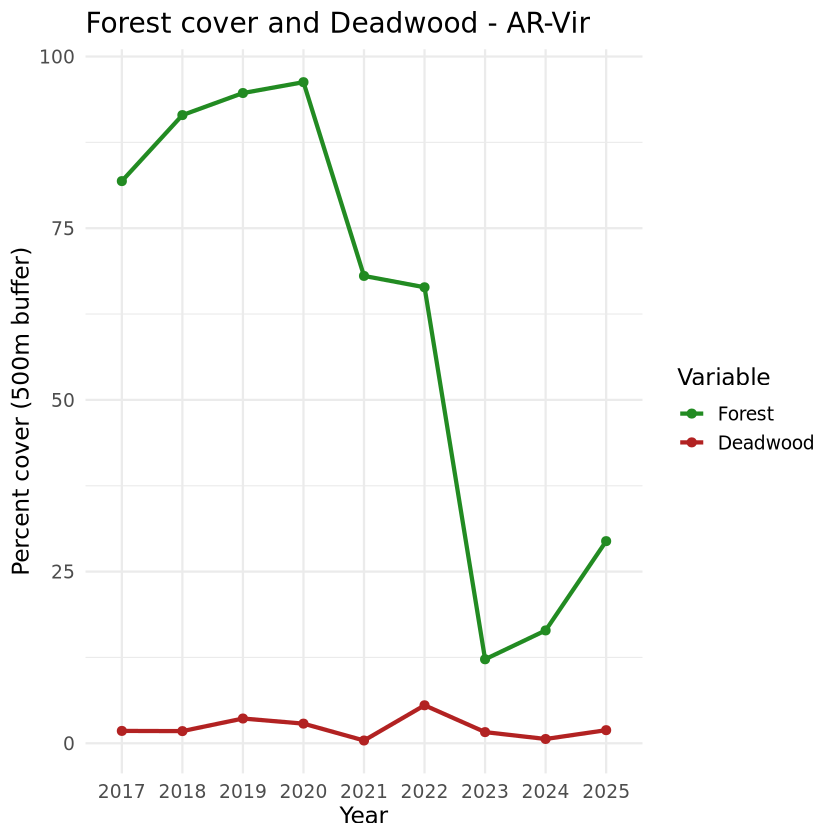

In [26]:
library(ggplot2)

p <- ggplot(dt_long, aes(x = as.factor(year), y = Value, color = Variable, group = Variable))
p <- ggplot_add(geom_line(linewidth = 1.2), p)
p <- ggplot_add(geom_point(size = 2), p)
p <- ggplot_add(
  scale_color_manual(values = c(
    "Forest" = "forestgreen",
    "Deadwood" = "firebrick"
  )),
  p
)
p <- ggplot_add(
  labs(
    title = paste("Forest cover and Deadwood -", first_site),
    x = "Year",
    y = "Percent cover (500m buffer)"
  ),
  p
)
p <- ggplot_add(theme_minimal(base_size = 14), p)
p

dir.create("deadwood_forestloss_output", showWarnings = FALSE)
ggsave(
  filename = file.path("deadwood_forestloss_output", paste0(first_site, "_deadwood_forestloss.png")),
  plot = p,
  width = 8,
  height = 6,
  dpi = 300
)

In [ ]:
### Loop toward all the sites
library(data.table)
library(ggplot2)

dir.create("deadwood_forestloss_output", showWarnings = FALSE)

site_col <- if ("site_id" %in% names(deadtree500)) "site_id" else "SITE_ID"
valid_sites <- deadtree500[, .(n_years = uniqueN(year)), by = .(site_key = get(site_col))][n_years > 1, site_key]

for (s in valid_sites) {
  dt_site <- deadtree500[get(site_col) == s]
  dt_long <- melt(
    dt_site,
    id.vars = "year",
    measure.vars = c("forest_mean_pct_500m", "deadwood_mean_pct_500m"),
    variable.name = "Variable",
    value.name = "Value"
  )

  dt_long <- dt_long[!is.na(Value)]
  if (nrow(dt_long) == 0) next

  dt_long[, Variable := factor(
    Variable,
    levels = c("forest_mean_pct_500m", "deadwood_mean_pct_500m"),
    labels = c("Forest", "Deadwood")
  )]

  p <- ggplot(dt_long, aes(x = as.factor(year), y = Value, color = Variable, group = Variable))
  p <- ggplot_add(geom_line(linewidth = 1.2), p)
  p <- ggplot_add(geom_point(size = 2), p)
  p <- ggplot_add(
    scale_color_manual(values = c("Forest" = "forestgreen", "Deadwood" = "firebrick")),
    p
  )
  p <- ggplot_add(
    labs(
      title = paste("Forest cover and Deadwood -", s),
      x = "Year",
      y = "Percent cover (500m buffer)"
    ),
    p
  )
  p <- ggplot_add(theme_minimal(base_size = 14), p)

  safe_name <- gsub("[^A-Za-z0-9_-]", "_", s)
  ggsave(
    filename = file.path("deadwood_forestloss_output", paste0(safe_name, "_deadwood_forestloss.png")),
    plot = p,
    width = 8,
    height = 6,
    dpi = 300
  )
}

cat("Saved", length(valid_sites), "plots to deadwood_forestloss_output\n")

Saved 348 plots to deadwood_forestloss_output


In [9]:
str(deadtree500)

Classes ‘data.table’ and 'data.frame':	3245 obs. of  7 variables:
 $ site_id                        : chr  "AR-SLu" "AR-SLu" "AR-SLu" "AR-SLu" ...
 $ year                           : int  2016 2017 2018 2019 2020 2021 2022 2023 2024 2017 ...
 $ forest_mean_pct_500m           : num  0.288 12.393 9.472 4.841 4.944 ...
 $ deadwood_mean_pct_500m         : num  0.5006 0.7925 0.1051 0.3461 0.0876 ...
 $ forest_change_pp_from_baseline : num  0 12.1 9.18 4.55 4.66 ...
 $ forest_change_pct_from_baseline: int  0 0 0 0 0 0 0 0 0 0 ...
 $ forest_change_pp_yoy           : num  NA 12.105 -2.921 -4.631 0.103 ...
 - attr(*, ".internal.selfref")=<externalptr> 


In [12]:
library(data.table)

# deadtree table you described
deadtree500 <- as.data.table(deadtree500)

# rename columns to 500m labels (as you requested)
setnames(deadtree500,
         old = c("site_id"),
         new = c("SITE_ID"),
         skip_absent = TRUE)

# remove any "_merged" suffix if present (just in case)
deadtree500[, SITE_ID := gsub("_merged$", "", SITE_ID)]

In [14]:
fwrite(deadtree500, "derived_tables/deadtree_deadwood_forest_siteyear_mean_500m.csv")

In [10]:
efp_climate <- as.data.table(efp_climate)




In [13]:
efp_climate_dead <- merge(
  efp_climate,
  deadtree500[, .(SITE_ID, year, forest_mean_pct_500m,deadwood_mean_pct_500m,forest_change_pp_from_baseline,forest_change_pp_yoy )],
  by = c("SITE_ID", "year"),
  all.x = TRUE
)

In [15]:
dir.create("derived_tables", showWarnings = FALSE, recursive = TRUE)

fwrite(
  efp_climate_dead,
  "derived_tables/EFP_site_year_with_climate_deadwood_forest_500m_06Mar26.csv"
)

In [16]:
View(efp_climate_dead)

SITE_ID,year,uWUE,ETmax,precipAvail,Gavail,GSmax,CO2avail,G1,EF,⋯,VPD_q90_m07.y,VPD_q90_m08.y,VPD_q90_m09.y,VPD_q90_m10.y,VPD_q90_m11.y,VPD_q90_m12.y,forest_mean_pct_500m,deadwood_mean_pct_500m,forest_change_pp_from_baseline,forest_change_pp_yoy
<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AR-SLu,2009,7.6758122,0.23525256,yes,yes,0.0086978262,yes,0.3358437,0.3127321,⋯,-9999.0000,-9999.0000,-9999.0000,-9999.0000,-9999.0000,35.6560,NA,NA,NA,NA
AR-SLu,2010,16.2402893,0.10641401,yes,yes,0.0026672316,yes,-0.5497535,0.1492497,⋯,11.1470,16.8320,20.8971,26.7665,32.0512,44.9839,NA,NA,NA,NA
AR-SLu,2011,10.6928793,0.13295070,yes,yes,0.0038752408,yes,-0.3088108,0.2533210,⋯,-9999.0000,-9999.0000,-9999.0000,-9999.0000,-9999.0000,-9999.0000,NA,NA,NA,NA
AR-Vir,2010,4.0743924,0.32438591,yes,yes,0.0007750829,yes,-0.8520437,0.8271577,⋯,11.9188,13.8890,13.8890,15.7278,22.8731,24.8118,NA,NA,NA,NA
AR-Vir,2011,3.7541200,0.26378451,yes,yes,0.0007116720,yes,-0.7099170,0.7727688,⋯,11.9236,15.4922,20.8689,21.2194,25.2458,22.7990,NA,NA,NA,NA
AR-Vir,2012,4.3087226,0.26984531,yes,yes,0.0006417871,yes,-1.0401099,0.6727284,⋯,-9999.0000,-9999.0000,-9999.0000,-9999.0000,-9999.0000,-9999.0000,NA,NA,NA,NA
AT-Neu,2002,3.9662324,0.34183833,yes,yes,0.0252128596,yes,2.6204606,0.8719508,⋯,13.8143,13.1693,8.3475,7.4479,3.5173,1.1936,NA,NA,NA,NA
AT-Neu,2003,4.5123157,0.28705336,yes,yes,0.0116077636,yes,1.0214599,0.8922966,⋯,16.8581,24.8252,13.1917,5.8810,5.9021,3.3741,NA,NA,NA,NA
AT-Neu,2004,3.8121818,0.28086398,yes,yes,0.0235160029,yes,2.8260133,0.8910636,⋯,14.8332,17.8759,10.8765,8.8414,2.5613,1.9018,NA,NA,NA,NA


In [17]:
# read data
efp_year <- fread("/mnt/gsdata/projects/panops/panops-data-registry/data/flux/derived_tables/EFP_site_year_with_climate_deadwood_forest_500m_06Mar26.csv")
traits <- fread("/mnt/gsdata/projects/panops/panops-data-registry/data/flux/derived_tables/flux_all_traits_hydro_incl.csv")

# check key column exists
names(efp_year)
names(traits)

# optional: keep only one row per SITE_ID in traits
traits_unique <- unique(traits, by = "SITE_ID")

# merge: keep all site-year rows, add static traits
efp_year_traits <- merge(
  efp_year,
  traits_unique,
  by = "SITE_ID",
  all.x = TRUE
)

[1] "SITE_ID"                        "year"                          
  [3] "uWUE"                           "ETmax"                         
  [5] "precipAvail"                    "Gavail"                        
  [7] "GSmax"                          "CO2avail"                      
  [9] "G1"                             "EF"                            
 [11] "EFampl"                         "GPPsat"                        
 [13] "NEPmax"                         "Rb"                            
 [15] "Rbmax"                          "aCUE"                          
 [17] "TZ"                             "nyears"                        
 [19] "LOCATION_LAT"                   "LOCATION_LONG"                 
 [21] "LOCATION_ELEV"                  "IGBP"                          
 [23] "P_mean_m01.x"                   "P_mean_m02.x"                  
 [25] "P_mean_m03.x"                   "P_mean_m04.x"                  
 [27] "P_mean_m05.x"                   "P_mean_m06.x"                  
 [29] "P_mean_m07.x"                   "P_mean_m08.x"                  
 [31] "P_mean_m09.x"                   "P_mean_m10.x"                  
 [33] "P_mean_m11.x"                   "P_mean_m12.x"                  
 [35] "P_q10_m01.x"                    "P_q10_m02.x"                   
 [37] "P_q10_m03.x"                    "P_q10_m04.x"                   
 [39] "P_q10_m05.x"                    "P_q10_m06.x"                   
 [41] "P_q10_m07.x"                    "P_q10_m08.x"                   
 [43] "P_q10_m09.x"                    "P_q10_m10.x"                   
 [45] "P_q10_m11.x"                    "P_q10_m12.x"                   
 [47] "P_q90_m01.x"                    "P_q90_m02.x"                   
 [49] "P_q90_m03.x"                    "P_q90_m04.x"                   
 [51] "P_q90_m05.x"                    "P_q90_m06.x"                   
 [53] "P_q90_m07.x"                    "P_q90_m08.x"                   
 [55] "P_q90_m09.x"                    "P_q90_m10.x"                   
 [57] "P_q90_m11.x"                    "P_q90_m12.x"                   
 [59] "SW_mean_m01.x"                  "SW_mean_m02.x"                 
 [61] "SW_mean_m03.x"                  "SW_mean_m04.x"                 
 [63] "SW_mean_m05.x"                  "SW_mean_m06.x"                 
 [65] "SW_mean_m07.x"                  "SW_mean_m08.x"                 
 [67] "SW_mean_m09.x"                  "SW_mean_m10.x"                 
 [69] "SW_mean_m11.x"                  "SW_mean_m12.x"                 
 [71] "SW_q10_m01.x"                   "SW_q10_m02.x"                  
 [73] "SW_q10_m03.x"                   "SW_q10_m04.x"                  
 [75] "SW_q10_m05.x"                   "SW_q10_m06.x"                  
 [77] "SW_q10_m07.x"                   "SW_q10_m08.x"                  
 [79] "SW_q10_m09.x"                   "SW_q10_m10.x"                  
 [81] "SW_q10_m11.x"                   "SW_q10_m12.x"                  
 [83] "SW_q90_m01.x"                   "SW_q90_m02.x"                  
 [85] "SW_q90_m03.x"                   "SW_q90_m04.x"                  
 [87] "SW_q90_m05.x"                   "SW_q90_m06.x"                  
 [89] "SW_q90_m07.x"                   "SW_q90_m08.x"                  
 [91] "SW_q90_m09.x"                   "SW_q90_m10.x"                  
 [93] "SW_q90_m11.x"                   "SW_q90_m12.x"                  
 [95] "TA_mean_m01.x"                  "TA_mean_m02.x"                 
 [97] "TA_mean_m03.x"                  "TA_mean_m04.x"                 
 [99] "TA_mean_m05.x"                  "TA_mean_m06.x"                 
[101] "TA_mean_m07.x"                  "TA_mean_m08.x"                 
[103] "TA_mean_m09.x"                  "TA_mean_m10.x"                 
[105] "TA_mean_m11.x"                  "TA_mean_m12.x"                 
[107] "TA_q10_m01.x"                   "TA_q10_m02.x"                  
[109] "TA_q10_m03.x"                   "TA_q10_m04.x"                  
[111] "TA_q10_m05.x"                   "TA

[1] "SITE_ID"               "LOCATION_LAT"          "LOCATION_LONG"        
 [4] "LOCATION_ELEV"         "IGBP"                  "gsmax_mean"           
 [7] "P12_mean"              "P50_mean"              "P88_mean"             
[10] "rdmax_mean"            "WUE_mean"              "IGBP.y"               
[13] "LOCATION_LAT.y"        "LOCATION_LONG.y"       "LOCATION_ELEV.y"      
[16] "Leaf C"                "Leaf N (mass)"         "Leaf width"           
[19] "Leaf C/N ratio"        "Leaf P"                "Stem conduit density" 
[22] "Stem conduit diameter" "Leaf area (3112)"      "Leaf area"            
[25] "Leaf area (3114)"      "SLA"                   "SSD"                  
[28] "Leaf thickness"        "Leaf N (area)"         "Leaf dry mass"        
[31] "Rooting depth"         "Leaf delta 15N"

Warning message in merge.data.table(efp_year, traits_unique, by = "SITE_ID", all.x = TRUE):
“column names [IGBP.y, LOCATION_LAT.y, LOCATION_LONG.y, LOCATION_ELEV.y] are duplicated in the result”


In [18]:
# save if needed
fwrite(
  efp_year_traits,
  "/mnt/gsdata/projects/panops/panops-data-registry/data/flux/derived_tables/modelready_06Mar26.csv"
)